k_MEAN CLUSTERING (UNSUPERVISED LEARNING)

[3 2 1 0 2 2 3 2 1 2 1 0 1 0 2 1 0 3 3 0 1 0 1 3 3 2 2 3 3 0 2 0 0 0 2 2 1
 1 3 3 2 1 0 0 0 1 1 1 2 3 2 0 3 2 1 0 0 3 2 3 3 0 2 3 1 2 2 3 1 2 1 2 2 3
 0 3 0 2 1 0 2 1 2 0 3 3 3 3 1 0 3 2 1 2 1 3 0 1 0 3 1 1 1 3 3 0 0 3 0 3 2
 3 3 3 3 2 1 3 2 2 0 1 2 1 3 1 1 2 2 3 3 1 1 2 1 3 3 3 1 1 2 3 1 1 2 3 3 0
 0 0 2 2 1 1 0 3 0 3 2 2 3 3 1 1 2 0 1 2 3 3 2 0 0 3 3 0 0 2 2 2 0 3 0 0 3
 3 0 1 0 2 2 3 3 2 0 2 0 0 3 2 0 0 2 3 1 3 2 1 1 3 3 2 3 0 0 2 0 3 0 1 1 0
 3 0 1 0 0 2 2 1 2 1 0 2 3 2 0 2 1 1 1 2 0 1 3 3 1 0 0 2 0 0 0 0 1 1 3 0 2
 1 0 0 3 0 2 2 1 0 1 2 0 0 1 3 0 0 0 1 3 2 0 1 1 0 2 0 1 3 1 2 2 0 0 1 3 1
 3 1 2 1 2 3 1 1 0 1 2 2 1 1 2 3 1 1 1 2 3 1 1 1 3 1 1 3 3 3 2 3 3 3 3 3 0
 3 1 3 0 0 3 1 1 1 0 0 2 0 2 0 1 2 2 1 2 3 3 2 3 0 2 0 1 0 2 2 3 1 2 1 1 3
 0 2 1 2 3 1 3 1 3 3 2 3 0 2 3 2 0 2 3 2 3 1 0 0 2 2 1 0 0 0 1 3 2 0 1 1 2
 3 2 2 2 0 1 2 0 1 0 0 1 0 1 0 3 2 1 0 2 3 0 1 1 2 2 2 3 2 1 3 0 0 3 1 3 1
 0 2 2 2 0 1 1 3 0 2 2 2 1 2 0 1 3 1 2 1 0 1 0 1 2 0 3 3 0 0 3 3 0 2 1 2 1
 0 3 3 0 2 3 3 1 3 3 0 3 

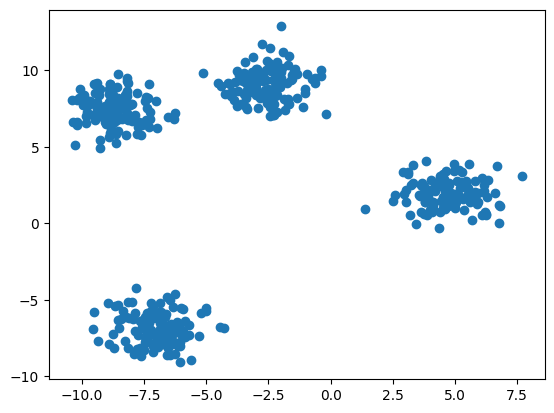

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=500,centers=4,random_state=42)   # CREATE A DATASET FOR K MEAN CLUSTERING . X IS A ARRAY CONTAING
                                                          # THE (x,y) CORDINATES AND y IS THE LABELS OF THE CLUSTERS
plt.scatter(X[:,0],X[:,1])
print(y)

In [2]:
class Kmeans:                                                        # CREATING A CLASS K_MEAN SO THAT WE CAN STORE ALL THE RELATED FUNCTIONS 
                                                                     #IN ONE PLACE IT NOR NECESSARY TO USE A CLASS , IT IS JUST THAT MAKES CODE EASY TO UNDERSTAND
    

    def __init__(self,no_clusters=2,max_iteration=100):            #CONSTRCUTOR FOR INITIALOSING THE VALUES
                                                                   # NO_CLUSTER,MAX_ITERATION ARE DEFAULT PARAMETER 
        self.k=no_clusters
        self.max_iteration=max_iteration
        self.centroids=None

    def fit(self,X):
        random_index=random.sample(range(0,X.shape[0]),self.k)  
        print(random_index)
        self.centroids=X[random_index]  
        print(self.centroids)
        



        for i in range(X.shape[0]):
             
             cluster_group= self.assign_clusters(X)
             old_clusters=self.centroids
             self.centroids=self.update_centroids(X,cluster_group)
             
             if (old_clusters==self.centroids).all():
                  break
                  
        return cluster_group


    def assign_clusters(self,X):  
            cluster_group=[]
            distance=[]
            for row in X:
                for centroid in self.centroids:
                    distance.append(np.sqrt(np.dot(row-centroid,row-centroid)))
                min_distance=min(distance)
                index=distance.index(min_distance)   
                cluster_group.append(index)
                distance.clear()
            return np.array(cluster_group)      

    def     update_centroids(self,X,cluster_group):
         new_centroids=[]
         cluster_type=np.unique(cluster_group)
         for type in cluster_type:
              mean=X[cluster_group==type].mean(axis=0)
              new_centroids.append(mean)
         return np.array(new_centroids)     
         
         

[270, 289, 20, 88]
[[-2.25870477  9.36073434]
 [-6.69776094 -6.63188901]
 [ 3.24131126  2.53613892]
 [ 4.08622953  0.77529179]]


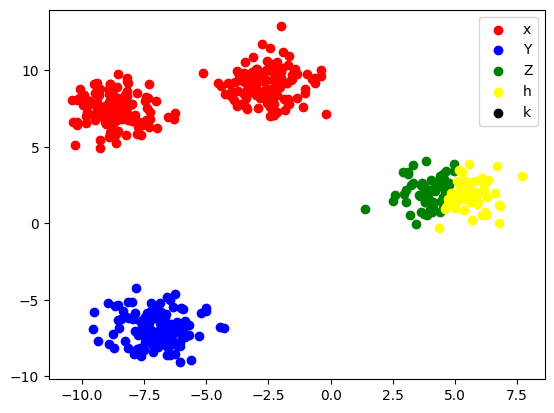

In [3]:
kmean=Kmeans(no_clusters=4,max_iteration=1000)
y_means=kmean.fit(X)

                                             # " x[y_means==0] "it will print ALL THe VALUES OF X THAT ARE INSIDE CLUSTER 0 
                                             # "x[y__means==0,0]" IT WILL PRINT ALL THE VALUES OF X[0] THAT ARE INSIDE CLUSTER 0 
#print(X[y_means==0])                                             
#print(y_means.shape)

plt.scatter(X[y_means==0,0],X[y_means==0,1],color="red",label="x")
plt.scatter(X[y_means==1,0],X[y_means==1,1],color="blue",label="Y")
plt.scatter(X[y_means==2,0],X[y_means==2,1],color="green",label="Z")
plt.scatter(X[y_means==3,0],X[y_means==3,1],color="yellow",label="h")
plt.legend()
plt.show()
